In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from typing import Literal, Union

## 1. Carga e inspección rápida de datos

In [2]:
df = pd.read_excel('Saldo_cosechas_20251201.xlsx')
df

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI5+,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI
0,111120220600071,1,0,2022-06-01,2022-07-01,107677.16,94927.53,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
1,111120220600071,2,0,2022-06-01,2022-08-01,107677.16,93876.24,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
2,111120220600071,3,0,2022-06-01,2022-09-01,107677.16,92797.52,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
3,111120220600071,4,0,2022-06-01,2022-10-01,107677.16,91690.63,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
4,111120220600071,5,0,2022-06-01,2022-11-01,107677.16,82523.46,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69390,111120251002556,1,0,2025-10-01,2025-11-01,277638.50,277638.50,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
69391,111120251002572,1,0,2025-10-01,2025-11-01,208019.56,208019.56,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
69392,111120251002630,1,0,2025-10-01,2025-11-01,222809.23,221314.66,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
69393,111120251002639,1,0,2025-10-01,2025-11-01,182272.09,180294.47,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN


In [3]:
df.columns

Index(['folio', 'MOB', 'pv', 'Fecha de Inicio', 'Mes-Año', 'Monto Fondeado',
       'Saldo Capital', 'Tipo de Castigo', 'Estatus Legal', 'BGI4+', 'Finan',
       'Mob Castigo', 'Trimestre', 'BGI4+_MAX', 'BGI4+_CONTEO',
       'BGI4+_CONTEO_EVER', 'CONTEO_FINAN', 'BGI2+', 'BGI3+', 'BGI5+',
       'BGI2+_CONTEO', 'BGI3+_CONTEO', 'BGI5+_CONTEO', 'BGI2+_CONTEO_EVER',
       'BGI3+_CONTEO_EVER', 'BGI5+_CONTEO_EVER', 'CAST_VAL', 'CAST_CONTEO',
       'CAST_VAL_ORI'],
      dtype='object')

In [4]:
df['Finan']

0        107677.16
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
69390    277638.50
69391    208019.56
69392    222809.23
69393    182272.09
69394    270971.26
Name: Finan, Length: 69395, dtype: float64

In [3]:
df.head(150).to_csv('extracto_df.csv', index=False)

In [2]:
df_extracto = pd.read_csv('extracto_df.csv')
df_extracto

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI5+,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI
0,111120220600071,1,0,2022-06-01,2022-07-01,107677.16,94927.5300,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
1,111120220600071,2,0,2022-06-01,2022-08-01,107677.16,93876.2400,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
2,111120220600071,3,0,2022-06-01,2022-09-01,107677.16,92797.5200,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
3,111120220600071,4,0,2022-06-01,2022-10-01,107677.16,91690.6300,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
4,111120220600071,5,0,2022-06-01,2022-11-01,107677.16,82523.4600,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,111120220700019,25,0,2022-07-01,2024-08-01,95866.00,59338.9500,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
146,111120220700019,26,0,2022-07-01,2024-09-01,95866.00,57377.8667,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
147,111120220700019,27,0,2022-07-01,2024-10-01,95866.00,55368.7100,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
148,111120220700019,28,0,2022-07-01,2024-11-01,95866.00,53311.6300,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN


In [4]:
df.columns

Index(['folio', 'MOB', 'pv', 'Fecha de Inicio', 'Mes-Año', 'Monto Fondeado',
       'Saldo Capital', 'Tipo de Castigo', 'Estatus Legal', 'BGI4+', 'Finan',
       'Mob Castigo', 'Trimestre', 'BGI4+_MAX', 'BGI4+_CONTEO',
       'BGI4+_CONTEO_EVER', 'CONTEO_FINAN', 'BGI2+', 'BGI3+', 'BGI5+',
       'BGI2+_CONTEO', 'BGI3+_CONTEO', 'BGI5+_CONTEO', 'BGI2+_CONTEO_EVER',
       'BGI3+_CONTEO_EVER', 'BGI5+_CONTEO_EVER', 'CAST_VAL', 'CAST_CONTEO',
       'CAST_VAL_ORI'],
      dtype='object')

In [27]:
df_p = df[(df['Fecha de Inicio'] == '2022-09-01') & (df['MOB'] == 1)]
df_p

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI5+,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI
633,111120220800054,1,0,2022-09-01,2022-10-01,95000.000,93311.600,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
905,111120220800080,1,0,2022-09-01,2022-10-01,209545.160,177397.760,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1177,111120220800116,1,0,2022-09-01,2022-10-01,249760.140,247861.650,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1215,111120220800118,1,0,2022-09-01,2022-10-01,130000.000,128833.000,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1253,111120220800122,1,0,2022-09-01,2022-10-01,344717.570,0.000,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1291,111120220800123,1,0,2022-09-01,2022-10-01,119000.000,117830.640,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1329,111120220800132,1,0,2022-09-01,2022-10-01,200500.000,198236.390,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1367,111120220900002,1,0,2022-09-01,2022-10-01,180000.000,178631.770,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1405,111120220900003,1,0,2022-09-01,2022-10-01,162256.480,161023.120,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN
1443,111120220900007,1,0,2022-09-01,2022-10-01,220000.000,218327.720,NaN,NaN,0.000,...,0.000,0,0,0,0,0,0,0.000,0,NaN


In [28]:
df_p['Monto Fondeado'].sum()

5472539.9795

In [ ]:
107677.16+915900.0

In [18]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df_finan = df[['Fecha de Inicio', 'Finan', 'CONTEO_FINAN']]
df_finan[df['CONTEO_FINAN'] == 1].groupby('Fecha de Inicio').sum('Finan')

,Finan,CONTEO_FINAN
Fecha de Inicio,,
2022-06-01,107677.160,1.000
2022-07-01,915900.000,7.000
2022-08-01,3182186.050,20.000
2022-09-01,5472539.980,36.000
2022-10-01,5616771.100,41.000
2022-11-01,5071810.950,34.000
2022-12-01,7175036.102,46.000
2023-01-01,10530727.240,68.000
2023-02-01,11923880.439,82.000


In [5]:
df[df['BGI4+'] > 0].head(10)

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI5+,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI
1109,111120220800099,11,4,2022-08-01,2023-07-01,154995.97,148814.63,Mora,Mora,148814.63,...,0.00,1,1,0,1,1,0,0.00,0,NaN
1121,111120220800099,23,4,2022-08-01,2024-07-01,154995.97,131525.09,Mora,Mora,131525.09,...,0.00,1,1,0,1,1,0,0.00,0,NaN
1122,111120220800099,24,4,2022-08-01,2024-08-01,154995.97,129717.33,Mora,Mora,129717.33,...,0.00,1,1,0,1,1,0,0.00,0,NaN
1123,111120220800099,25,5,2022-08-01,2024-09-01,154995.97,129717.33,Mora,Mora,129717.33,...,129717.33,1,1,1,1,1,1,0.00,0,NaN
1124,111120220800099,26,5,2022-08-01,2024-10-01,154995.97,127866.06,Mora,Mora,127866.06,...,127866.06,1,1,1,1,1,1,0.00,0,NaN
1125,111120220800099,27,7,2022-08-01,2024-11-01,154995.97,127866.06,Mora,Mora,127866.06,...,127866.06,1,1,1,1,1,1,127866.06,1,127866.06
1126,111120220800099,28,7,2022-08-01,2024-12-01,154995.97,125866.06,Mora,Mora,125866.06,...,125866.06,1,1,1,1,1,1,125866.06,1,127866.06
1127,111120220800099,29,7,2022-08-01,2025-01-01,154995.97,123866.06,Mora,Mora,123866.06,...,123866.06,1,1,1,1,1,1,123866.06,1,127866.06
1128,111120220800099,30,7,2022-08-01,2025-02-01,154995.97,122366.06,Mora,Mora,122366.06,...,122366.06,1,1,1,1,1,1,122366.06,1,127866.06
1129,111120220800099,31,7,2022-08-01,2025-03-01,154995.97,122366.06,Mora,Mora,122366.06,...,122366.06,1,1,1,1,1,1,122366.06,1,127866.06


In [6]:
df[df['Saldo Capital'] > 0].head(10)

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI5+,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI
0,111120220600071,1,0,2022-06-01,2022-07-01,107677.16,94927.53,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
1,111120220600071,2,0,2022-06-01,2022-08-01,107677.16,93876.24,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
2,111120220600071,3,0,2022-06-01,2022-09-01,107677.16,92797.52,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
3,111120220600071,4,0,2022-06-01,2022-10-01,107677.16,91690.63,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
4,111120220600071,5,0,2022-06-01,2022-11-01,107677.16,82523.46,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
5,111120220600071,6,0,2022-06-01,2022-12-01,107677.16,81461.39,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
6,111120220600071,7,0,2022-06-01,2023-01-01,107677.16,80371.61,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
7,111120220600071,8,0,2022-06-01,2023-02-01,107677.16,79253.39,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
8,111120220600071,9,0,2022-06-01,2023-03-01,107677.16,78105.98,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN
9,111120220600071,10,0,2022-06-01,2023-04-01,107677.16,76928.62,NaN,NaN,0.0,...,0.0,0,0,0,0,0,0,0.0,0,NaN


## 2. Cálculo de la matriz de % de impago en cosecha

In [47]:
def calc_pct_impago(
    data: Union[pd.DataFrame, pd.Series, dict],
    *,
    mode: Literal["raw", "agg"] = "raw",
    bgi_col: str = "BGI4+",
    saldo_col: str = "Monto Fondeado",
    bgi_sum_col: str = "bgi4_sum",
    saldo_sum_col: str = "saldo_sum",
) -> float:
    """
    Calcula el % de impago del portafolio.

    Definición base:
        % impago = sum(BGI) / sum(Saldo) * 100

    Modos:
    ------
    raw :
        `data` es un DataFrame crudo (clientes × mes, cohorte × MOB, etc.)
        Se calcula usando sumas internas.
    agg :
        `data` es una fila agregada (Series o dict) con:
        - bgi_sum_col
        - saldo_sum_col

    Parameters
    ----------
    data : DataFrame | Series | dict
        Datos crudos o agregados, dependiendo del modo.
    mode : {"raw", "agg"}
        Tipo de cálculo.
    bgi_col : str
        Columna BGI en datos crudos.
    saldo_col : str
        Columna de saldo en datos crudos.
    bgi_sum_col : str
        Nombre de la columna agregada de BGI.
    saldo_sum_col : str
        Nombre de la columna agregada de saldo.

    Returns
    -------
    float
        % de impago o NaN si el saldo es 0.
    """

    if mode == "raw":
        saldo_total = data[saldo_col].sum()
        if saldo_total <= 0:
            return np.nan
        return (data[bgi_col].sum() / saldo_total) * 100

    elif mode == "agg":
        # DataFrame completo (vectorizado)
        if isinstance(data, pd.DataFrame):
            saldo = data[saldo_sum_col].astype(float)
            bgi = data[bgi_sum_col].astype(float)

            out = np.full(len(data), np.nan, dtype=float)
            mask = saldo > 0
            out[mask.to_numpy()] = (bgi[mask] / saldo[mask]) * 100
            return pd.Series(out, index=data.index, name="pct_impago")

        # 1 fila (Series/dict)
        if isinstance(data, pd.DataFrame):
            data = data.iloc[0]

        saldo_total = float(data[saldo_sum_col])
        if saldo_total <= 0:
            return np.nan
        return (float(data[bgi_sum_col]) / saldo_total) * 100

    else:
        raise ValueError("mode debe ser 'raw' o 'agg'")


In [48]:
# Obtención de cohortes para el portafolio de préstamos en cada mes
df["Fecha de Inicio"] = pd.to_datetime(df["Fecha de Inicio"])
df["cohorte"] = df["Fecha de Inicio"].dt.to_period("M").dt.to_timestamp()

# Agregado por cohorte y MOB
agg = (df.groupby(["cohorte", "MOB"], as_index=False)
         .agg(bgi4_sum=("BGI4+", "sum"),
              saldo_sum=("Monto Fondeado", "sum")))

# % impago ponderado por saldo
agg["pct_impago"] = agg.apply(lambda r: calc_pct_impago(r, mode="agg"),axis=1)

# Matriz de % impago por cosecha (filas=cohorte, columnas=MOB)
matriz = agg.pivot(index="cohorte", columns="MOB", values="pct_impago").sort_index()
matriz

MOB,1,2,3,4,5,6,7,8,9,10,...,32,33,34,35,36,37,38,39,40,41
cohorte,,,,,,,,,,,,,,,,,,,,,
2022-06-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2022-07-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN
2022-08-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.845346,3.845346,3.845346,6.983685,6.983685,6.983685,6.983685,6.983685,NaN,NaN
2022-09-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.981889,3.981889,3.376777,4.708011,4.668025,4.493559,4.317245,NaN,NaN,NaN
2022-10-01,0.000000,0.000000,0.000000,0.089793,0.089793,0.089793,0.089793,0.089793,0.089793,0.089793,...,0.089793,0.089793,0.089793,0.089793,0.089793,3.933168,NaN,NaN,NaN,NaN
2022-11-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.396843,2.314382,2.314382,...,2.978173,2.978173,2.978173,2.978173,3.941295,NaN,NaN,NaN,NaN,NaN
2022-12-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.566653,9.566653,9.566653,9.566653,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.958418,3.227492,3.227492,...,10.029882,9.113574,9.080338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.175844,1.040205,1.040205,1.040205,...,5.121605,5.121605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
matriz.to_excel("Matriz_impago_cosecha.xlsx", merge_cells=False)

matriz_prueba_save = pd.read_excel("Matriz_impago_cosecha.xlsx", index_col=0)

# reconstruir tipos
matriz_prueba_save.index = pd.to_datetime(matriz_prueba_save.index, errors="coerce")
matriz_prueba_save.columns = pd.to_numeric(matriz_prueba_save.columns, errors="coerce")

# restaurar el "label" de columnas
matriz_prueba_save.columns.name = "MOB"
matriz_prueba_save.index.name = "cohorte"

matriz_prueba_save



MOB,1,2,3,4,5,6,7,8,9,10,...,32,33,34,35,36,37,38,39,40,41
cohorte,,,,,,,,,,,,,,,,,,,,,
2022-06-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2022-07-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN
2022-08-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,12.027510,12.442331,12.917082,24.529848,31.771433,32.975688,33.931773,34.971487,NaN,NaN
2022-09-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.219264,13.810718,13.400530,19.557128,20.152360,20.294384,21.086740,NaN,NaN,NaN
2022-10-01,0.000000,0.000000,0.000000,0.103207,0.107332,0.109579,0.114202,0.116589,0.118819,0.120977,...,0.290822,0.301342,0.311627,0.326546,0.338195,15.805691,NaN,NaN,NaN,NaN
2022-11-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.742775,2.693951,2.754039,...,9.050638,9.338321,9.662853,10.031508,14.265895,NaN,NaN,NaN,NaN,NaN
2022-12-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,25.296278,26.175176,27.032023,28.926933,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.504585,4.217138,4.407889,...,30.730529,30.243785,32.907046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.447304,1.317086,1.369635,1.460659,...,18.307400,19.381307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Validación del cálculo**

Tomamos los datos del cohorte "2022-08-01", y trataremos de replicar paso a paso lo calculado para le MOB 38, buscando obtener el 33.931773% que se muestra en la matriz de %impago de cosecha completa.

In [9]:
# Primero tomamos todos los registos del cohorte 2022-08-01 en el MOB 38
sub = df[(df["cohorte"] == "2022-08-01") & (df["MOB"] == 38)].copy()
sub

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI,cohorte
358,111120220800001,38,0,2022-08-01,2025-10-01,240821.38,0.0000,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
397,111120220800008,38,0,2022-08-01,2025-10-01,232000.00,0.0000,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
436,111120220800012,38,0,2022-08-01,2025-10-01,81611.10,0.0000,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
475,111120220800025,38,0,2022-08-01,2025-10-01,119000.00,0.0000,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
514,111120220800026,38,0,2022-08-01,2025-10-01,205574.66,97225.6500,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
553,111120220800031,38,0,2022-08-01,2025-10-01,153144.46,0.0000,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
592,111120220800037,38,0,2022-08-01,2025-10-01,118000.00,0.0000,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
631,111120220800053,38,0,2022-08-01,2025-10-01,300000.00,0.0031,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
708,111120220800059,38,0,2022-08-01,2025-10-01,171935.54,55029.8500,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
747,111120220800065,38,0,2022-08-01,2025-10-01,259379.18,139048.4600,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01


In [40]:
sub = df[(df["cohorte"] == "2022-08-01")].copy()
sub

,folio,MOB,pv,Fecha de Inicio,Mes-Año,Monto Fondeado,Saldo Capital,Tipo de Castigo,Estatus Legal,BGI4+,...,BGI2+_CONTEO,BGI3+_CONTEO,BGI5+_CONTEO,BGI2+_CONTEO_EVER,BGI3+_CONTEO_EVER,BGI5+_CONTEO_EVER,CAST_VAL,CAST_CONTEO,CAST_VAL_ORI,cohorte
321,111120220800001,1,0,2022-08-01,2022-09-01,240821.38,238990.83,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
322,111120220800001,2,0,2022-08-01,2022-10-01,240821.38,235196.61,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
323,111120220800001,3,0,2022-08-01,2022-11-01,240821.38,235196.61,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
324,111120220800001,4,0,2022-08-01,2022-12-01,240821.38,233230.67,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
325,111120220800001,5,0,2022-08-01,2023-01-01,240821.38,231217.29,NaN,NaN,0.00,...,0,0,0,0,0,0,0.00,0,NaN,2022-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172,111120220800105,35,4,2022-08-01,2025-07-01,148793.66,99867.78,Mora,Mora,99867.78,...,1,1,0,1,1,0,0.00,0,NaN,2022-08-01
1173,111120220800105,36,5,2022-08-01,2025-08-01,148793.66,99867.78,Mora,Mora,99867.78,...,1,1,1,1,1,1,0.00,0,NaN,2022-08-01
1174,111120220800105,37,6,2022-08-01,2025-09-01,148793.66,99867.78,Mora,Mora,99867.78,...,1,1,1,1,1,1,0.00,0,NaN,2022-08-01
1175,111120220800105,38,7,2022-08-01,2025-10-01,148793.66,99867.78,Mora,Mora,99867.78,...,1,1,1,1,1,1,99867.78,1,99867.78,2022-08-01


In [42]:
sub['BGI4+'].sum()

2768238.119999999

In [46]:
len(sub['folio'].unique())

20

In [10]:
# Calculamos la suma de los saldos para BGI4+
bgi4_sum = sub["BGI4+"].sum()

# Calculamos la suma de los saldos para todos los registros
saldo_sum = sub["Saldo Capital"].sum()

# Calculamos el % de impago como la relación de ambas cantidades
pct = (bgi4_sum / saldo_sum) * 100

In [11]:
print('Reporte de cálculos:')
print(f'\tSuma de saldos de BGI4+ en MOB 38: {bgi4_sum}')
print(f'\tSuma de saldos completos en MOB 38: {saldo_sum}')
print(f'\t% de impago para cohorte 2022-08-01 y MOB 38: {pct.round(6)}')

Reporte de cálculos:
	Suma de saldos de BGI4+ en MOB 38: 222233.84
	Suma de saldos completos en MOB 38: 654943.2031
	% de impago para cohorte 2022-08-01 y MOB 38: 33.931773


Derivado del cálculo paso a paso podemos ver que la implementación del cálculo de la mtriz es correcta, y se puede replicar dicho flujo y principio para cualquier métrica de interés.

## 3. Visualizaciones de la matriz

### 3.1 Heat map simple

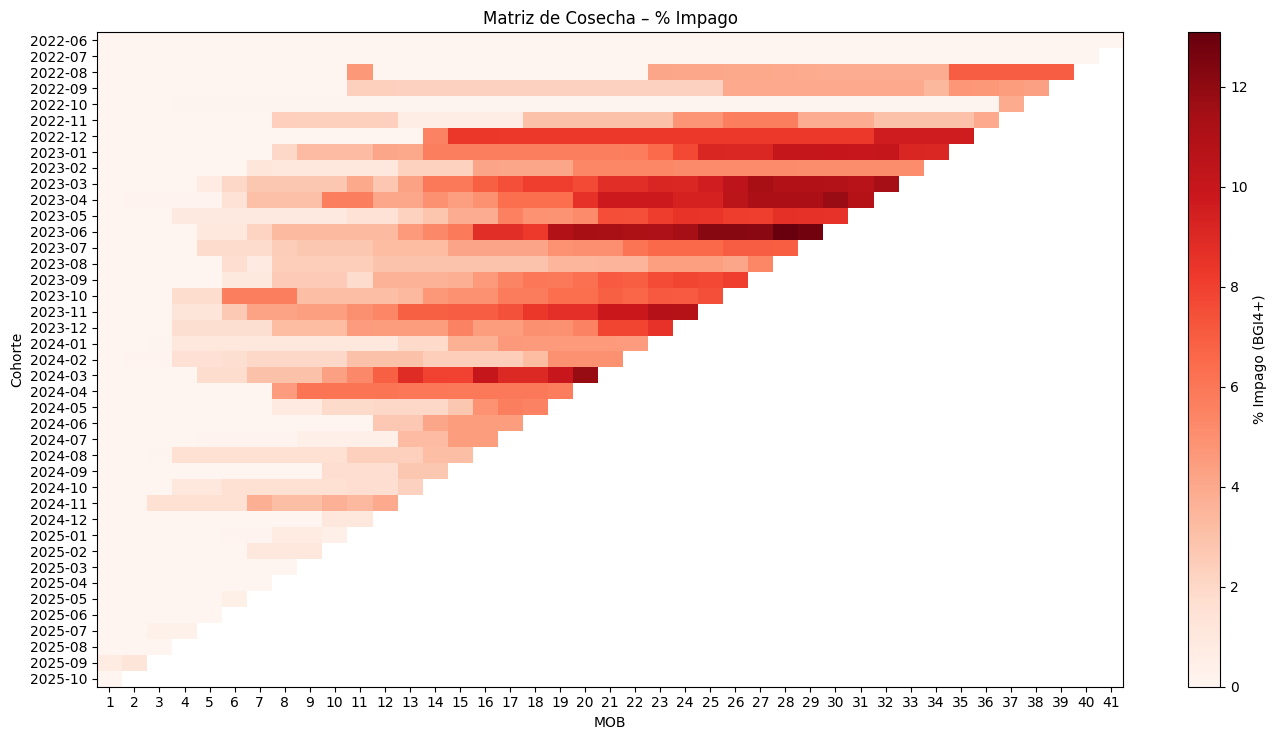

In [49]:
# Heatmap de la matriz
plt.figure(figsize=(14, 7.5))
plt.imshow(matriz, aspect="auto", cmap="Reds")
plt.colorbar(label="% Impago (BGI4+)")
plt.xlabel("MOB")
plt.ylabel("Cohorte")
plt.title("Matriz de Cosecha – % Impago")
plt.yticks(range(len(matriz.index)), matriz.index.strftime("%Y-%m"))
plt.xticks(range(len(matriz.columns)), matriz.columns)
plt.tight_layout()
plt.show()

### 3.2 Heatmap de cohortes selectos o rango de cohortes

In [13]:
def plot_harvest_cohort_view(
    matriz: pd.DataFrame,
    cohort_start=None,
    cohort_end=None,
    title=None,
    cmap="Reds",
    figsize=(10, 6)
):
    """
    Visualiza la matriz de cosecha con:
    - Cohortes en el eje X
    - MOB en el eje Y
    - Origen en la esquina inferior izquierda

    Parameters
    ----------
    matriz : pd.DataFrame
        Index = cohortes, Columns = MOB, Values = % impago
    cohort_start : str | pd.Timestamp | None
        Inicio del rango de cohortes (ej. '2024-01')
    cohort_end : str | pd.Timestamp | None
        Fin del rango de cohortes (ej. '2024-06')
    title : str | None
        Título del gráfico
    cmap : str
        Colormap
    figsize : tuple
        Tamaño de la figura
    """

    # Normalizar index a datetime 
    m = matriz.copy()
    if not isinstance(m.index, pd.DatetimeIndex):
        m.index = pd.to_datetime(m.index)

    # Filtrar cohortes
    if cohort_start is not None:
        cohort_start = pd.to_datetime(cohort_start)
        m = m.loc[m.index >= cohort_start]

    if cohort_end is not None:
        cohort_end = pd.to_datetime(cohort_end)
        m = m.loc[m.index <= cohort_end]

    if m.empty:
        raise ValueError("No hay cohortes en el rango seleccionado.")

    # Para el heatmap vertical
    m_t = m.T

    # Plot
    if cohort_start == cohort_end:
        plt.figure(figsize=(5, 7))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(
        m_t,
        aspect="auto",
        cmap=cmap,
        origin="lower"
    )

    plt.colorbar(label="% Impago (BGI4+)")
    plt.xlabel("Cohorte")
    plt.ylabel("MOB")

    if title is None:
        if cohort_start and cohort_end:
            if cohort_start == cohort_end:
                title = f"Matriz de Cosecha – Cohorte {cohort_start:%Y-%m}"
            else:
                title = f"Matriz de Cosecha – Cohortes {cohort_start:%Y-%m} a {cohort_end:%Y-%m}"
        elif cohort_start:
            title = f"Matriz de Cosecha – Cohorte {cohort_start:%Y-%m}"
        else:
            title = "Matriz de Cosecha"

    plt.title(title)

    # Ticks 
    plt.xticks(
        range(len(m_t.columns)),
        m_t.columns.strftime("%Y-%m"),
        rotation=90
    )
    plt.yticks(range(len(m_t.index)), m_t.index)

    plt.tight_layout()
    plt.show()


**Visualizació para un solo cohorte**

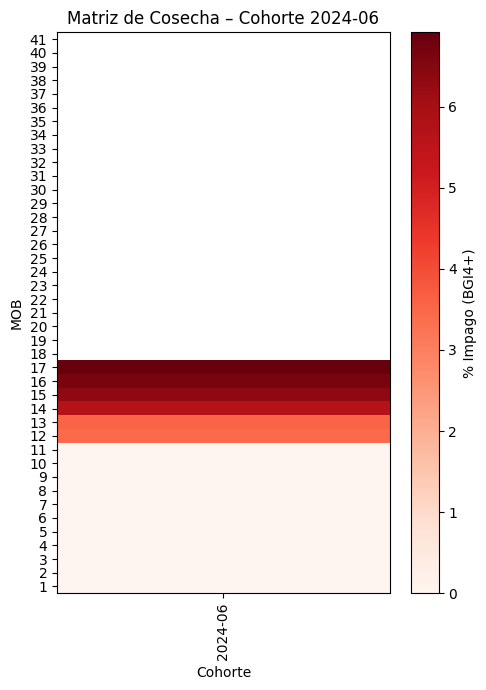

In [14]:
plot_harvest_cohort_view(
    matriz,
    cohort_start="2024-06",
    cohort_end="2024-06"
)

**Visualizació desde un cohorte específico hasta el final**

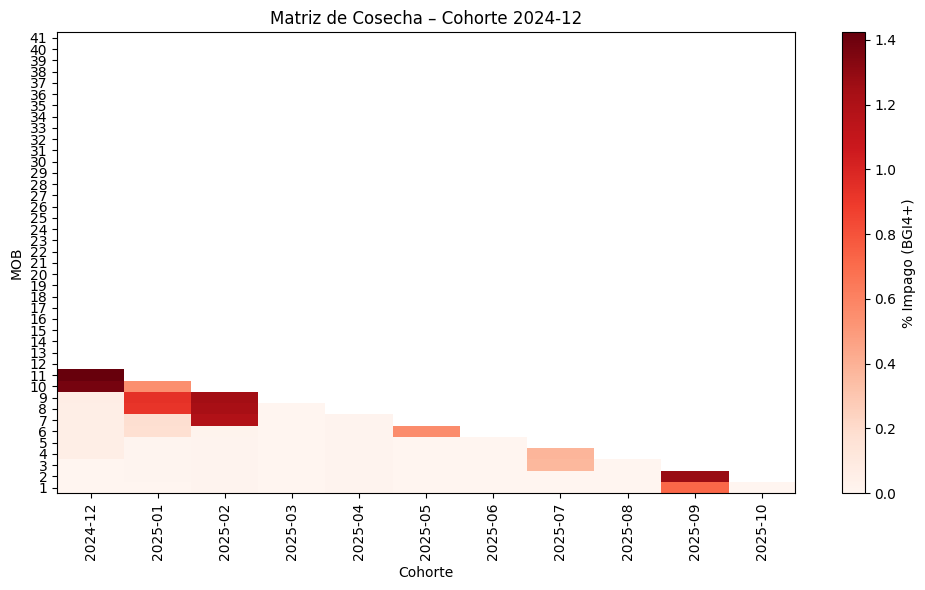

In [15]:
plot_harvest_cohort_view(
    matriz,
    cohort_start="2024-12"
)

**Visualizació para un rango de cohortes**

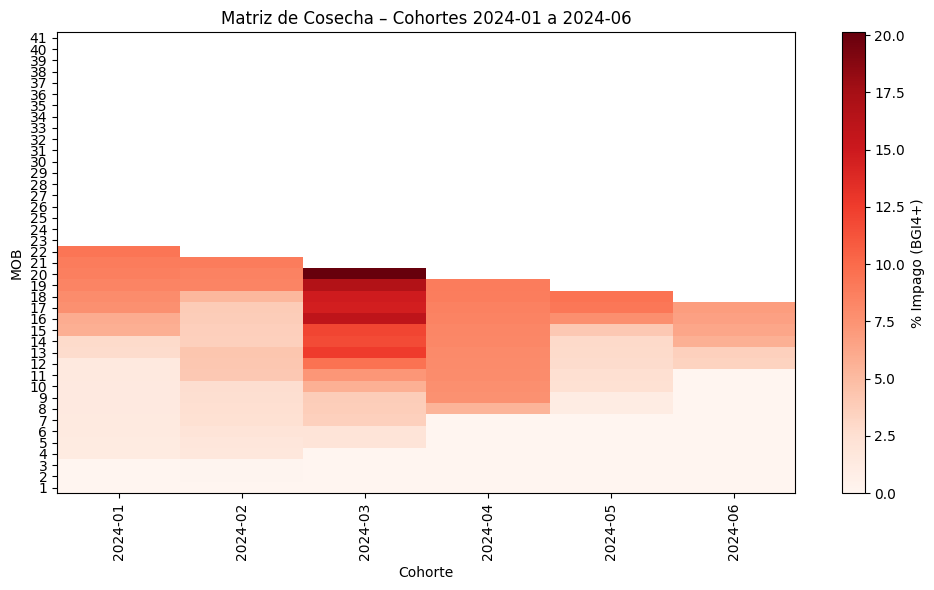

In [16]:
plot_harvest_cohort_view(
    matriz,
    cohort_start="2024-01",
    cohort_end="2024-06"
)

**Visualización de matriz completa**

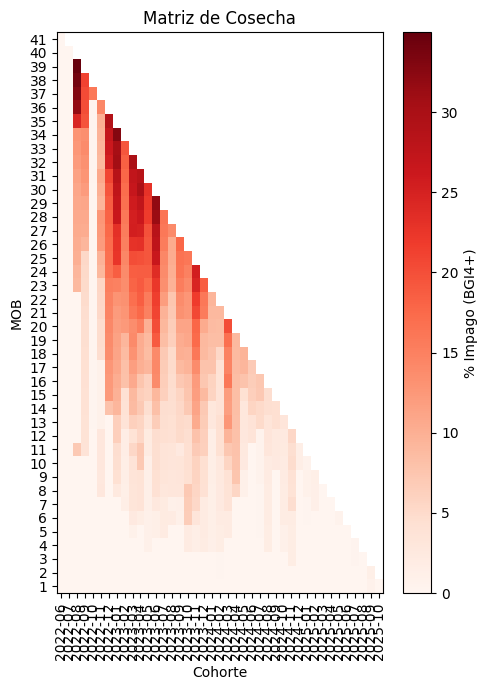

In [17]:
plot_harvest_cohort_view(
    matriz
)

### 3.2 Curvas de cosecha por cohorte

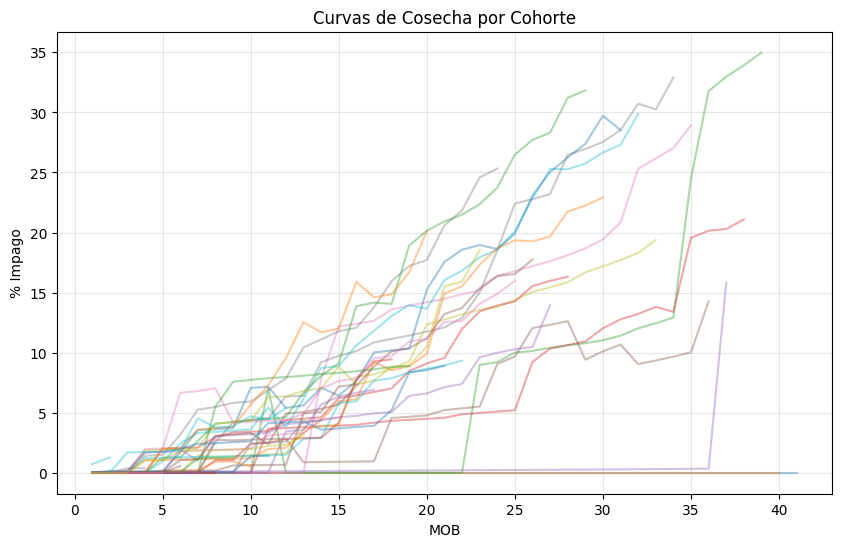

In [18]:
plt.figure(figsize=(10, 6))
for cohorte, row in matriz.iterrows():
    plt.plot(matriz.columns, row, alpha=0.4)

plt.xlabel("MOB")
plt.ylabel("% Impago")
plt.title("Curvas de Cosecha por Cohorte")
plt.grid(True, alpha=0.3)
plt.show()


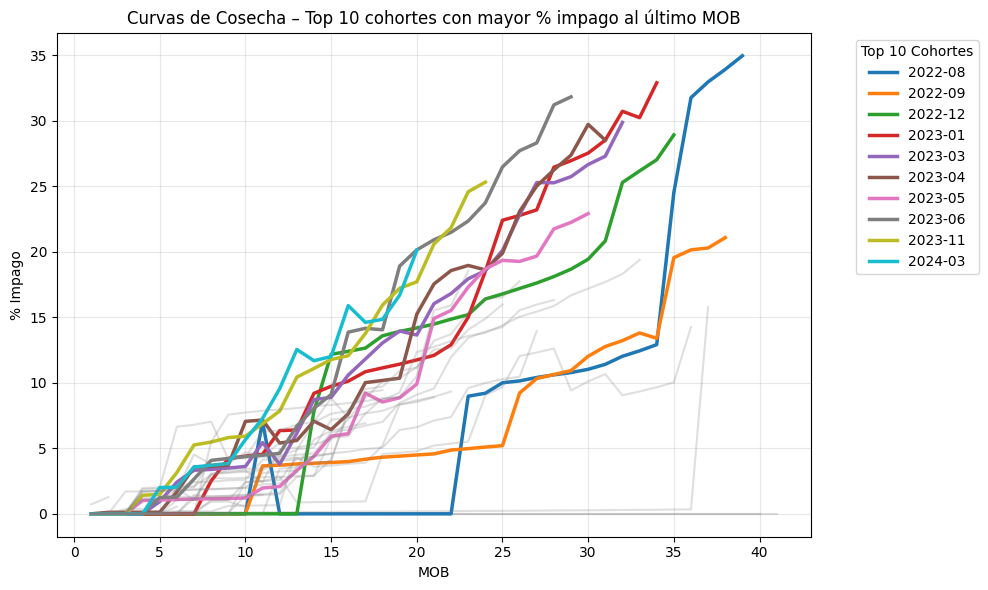

In [19]:
# 1) score = último valor disponible por cohorte
score = matriz.apply(lambda r: r.dropna().iloc[-1] if r.dropna().shape[0] else float("nan"), axis=1)

top10 = score.sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 6))

for cohorte, row in matriz.iterrows():
    if cohorte in top10:
        plt.plot(matriz.columns, row, label=cohorte.strftime("%Y-%m"), linewidth=2.5)
    else:
        plt.plot(matriz.columns, row, color="gray", alpha=0.25)

plt.xlabel("MOB")
plt.ylabel("% Impago")
plt.title("Curvas de Cosecha – Top 10 cohortes con mayor % impago al último MOB")
plt.legend(title="Top 10 Cohortes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


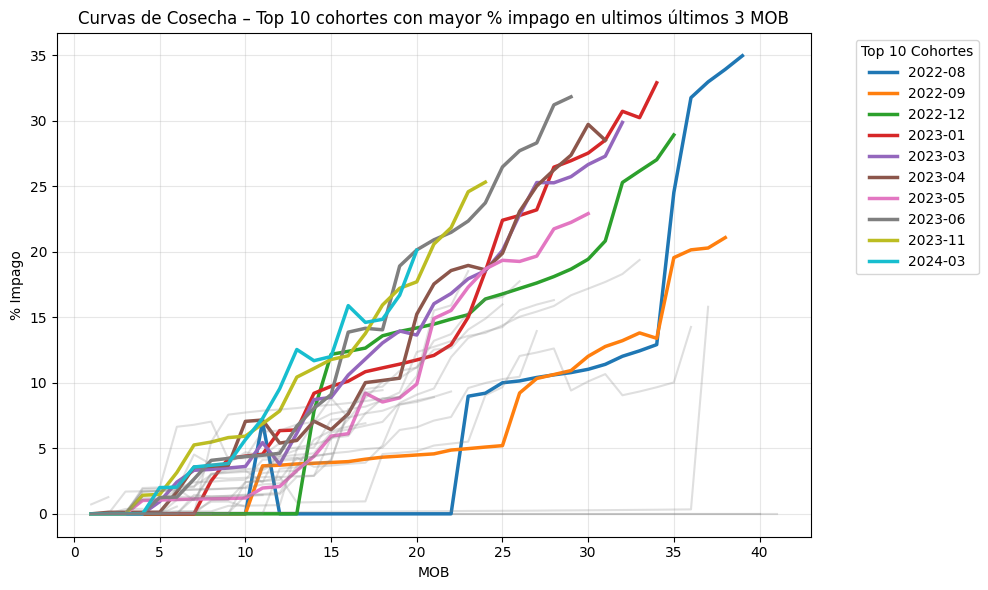

In [20]:
N = 3 # Para promediar los últimos "N" meses del cohorte
score = matriz.apply(lambda r: r.dropna().tail(N).mean() if r.dropna().shape[0] else float("nan"), axis=1)
top10 = score.sort_values(ascending=False).head(10).index
score = matriz.apply(lambda r: r.dropna().iloc[-1] if r.dropna().shape[0] else float("nan"), axis=1)

top10 = score.sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 6))

for cohorte, row in matriz.iterrows():
    if cohorte in top10:
        plt.plot(matriz.columns, row, label=cohorte.strftime("%Y-%m"), linewidth=2.5)
    else:
        plt.plot(matriz.columns, row, color="gray", alpha=0.25)

plt.xlabel("MOB")
plt.ylabel("% Impago")
plt.title(f"Curvas de Cosecha – Top 10 cohortes con mayor % impago en ultimos últimos {N} MOB")
plt.legend(title="Top 10 Cohortes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

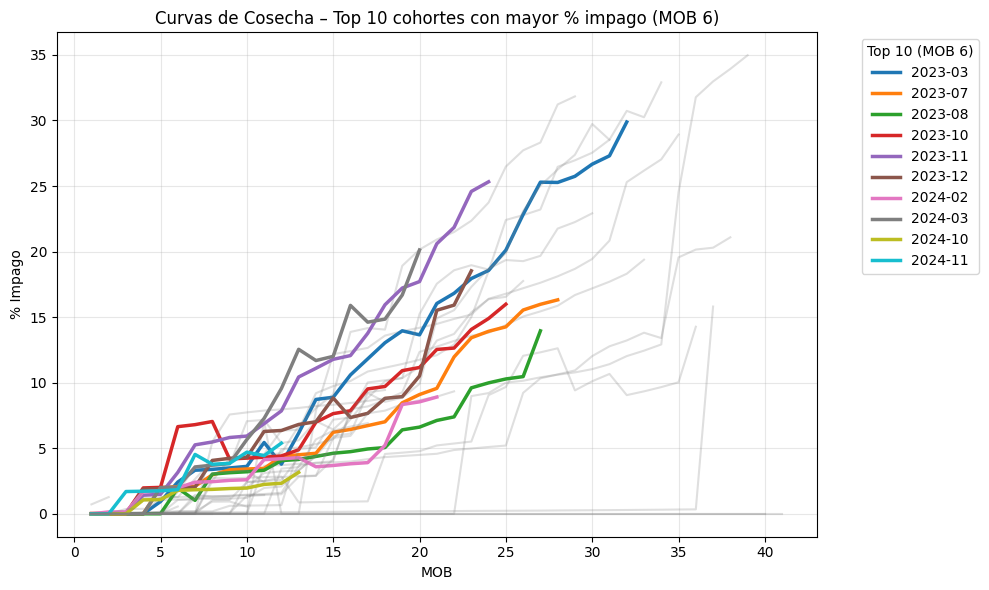

In [21]:
mob_k = 6   # MOB a inspeccionar en todos los cohortes

score = matriz.get(mob_k)  
top10 = score.sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 6))

for cohorte, row in matriz.iterrows():
    if cohorte in top10:
        plt.plot(matriz.columns, row, label=cohorte.strftime("%Y-%m"), linewidth=2.5)
    else:
        plt.plot(matriz.columns, row, color="gray", alpha=0.25)

plt.xlabel("MOB")
plt.ylabel("% Impago")
plt.title(f"Curvas de Cosecha – Top 10 cohortes con mayor % impago (MOB {mob_k})")
plt.legend(title=f"Top 10 (MOB {mob_k})", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Curvas promedio de impago en portafolio completo

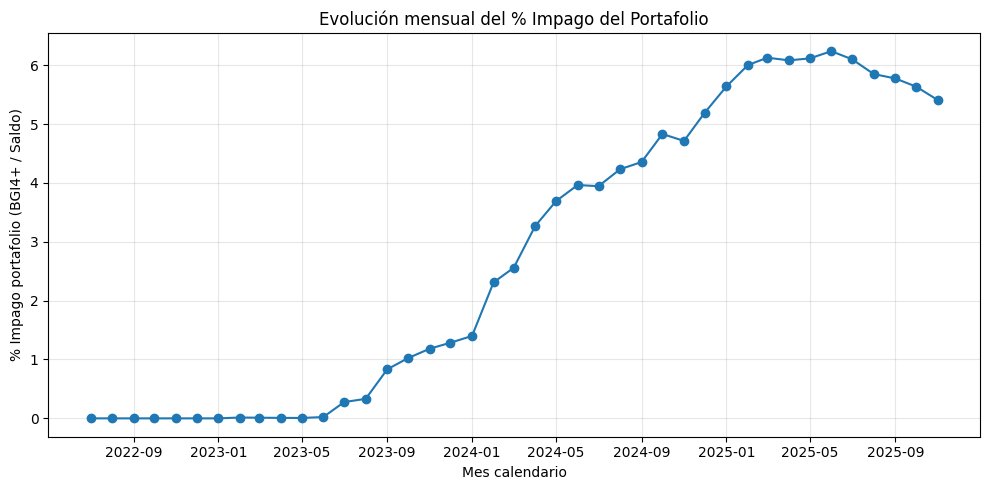

In [34]:
# Normalizar fechas
df["Mes-Año"] = pd.to_datetime(df["Mes-Año"], errors="coerce")
df["Fecha de Inicio"] = pd.to_datetime(df["Fecha de Inicio"], errors="coerce")

# (Opcional) cohortes para auditoría
df["cohorte"] = df["Fecha de Inicio"].dt.to_period("M").dt.to_timestamp()

# Agregar por mes calendario (snapshot del portafolio vivo en ese mes)
ts = (
    df.groupby("Mes-Año", as_index=True)
      .agg(
          bgi4_sum=("BGI4+", "sum"),
          saldo_sum=("Saldo Capital", "sum")
      )
      .sort_index()
)

# % impago (USANDO calc_pct_impago, vectorizado)
ts["pct_impago_portafolio"] = calc_pct_impago(ts, mode="agg")

# Plot (igual que antes)
plt.figure(figsize=(10, 5))
plt.plot(ts.index, ts["pct_impago_portafolio"], marker="o")
plt.xlabel("Mes calendario")
plt.ylabel("% Impago portafolio (BGI4+ / Saldo)")
plt.title("Evolución mensual del % Impago del Portafolio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


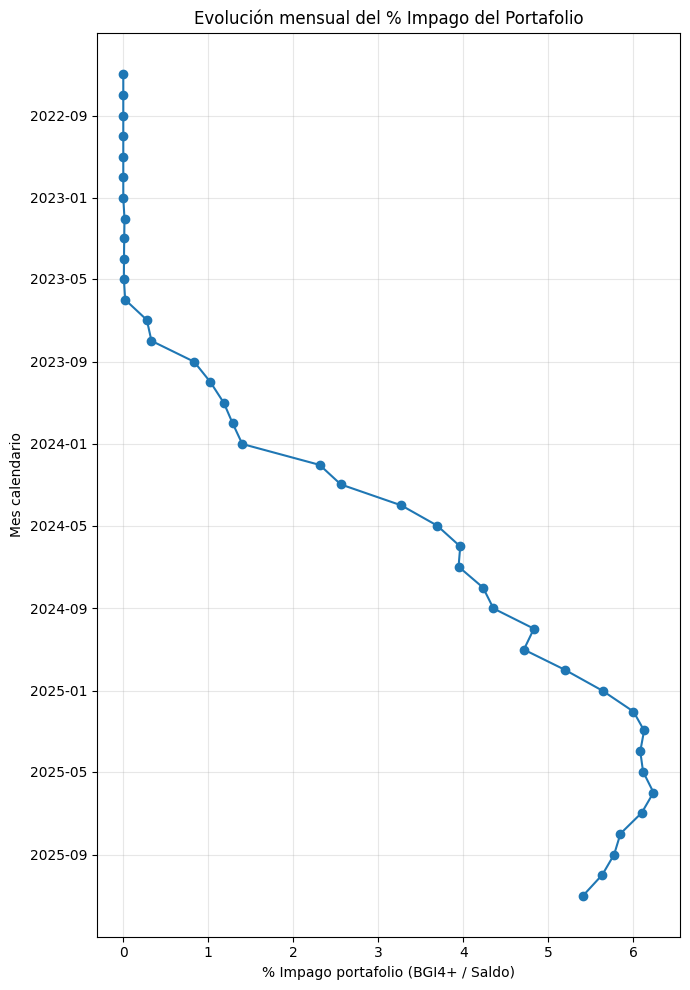

In [35]:
plt.figure(figsize=(7, 10))

plt.plot(
    ts["pct_impago_portafolio"],  # X
    ts.index,                     # Y
    marker="o"
)

plt.xlabel("% Impago portafolio (BGI4+ / Saldo)")
plt.ylabel("Mes calendario")
plt.title("Evolución mensual del % Impago del Portafolio")
plt.grid(True, alpha=0.3)

# Opcional: fechas antiguas arriba, recientes abajo
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


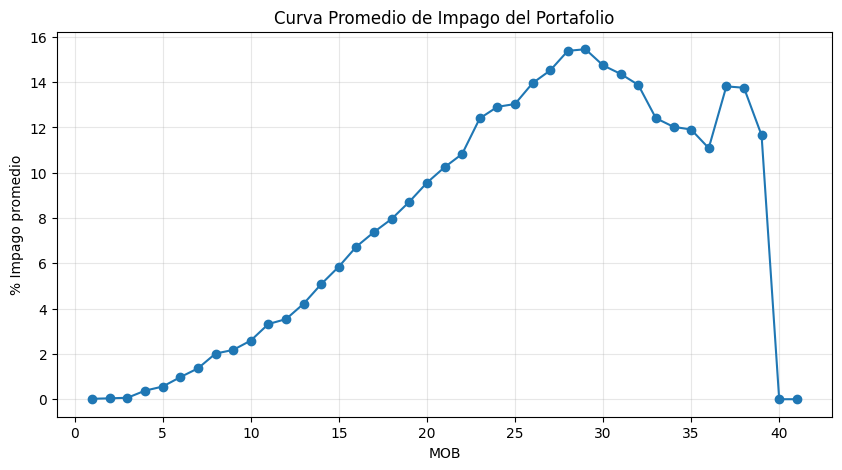

In [22]:
"""
Comportamiento promedio del % de impago de las cohortes del portafolio conforme envejecen, 
alineadas por meses desde la originación.
"""
plt.figure(figsize=(10, 5))
plt.plot(matriz.columns, matriz.mean(), marker="o")
plt.xlabel("MOB")
plt.ylabel("% Impago promedio")
plt.title("Curva Promedio de Impago del Portafolio")
plt.grid(True, alpha=0.3)
plt.show()

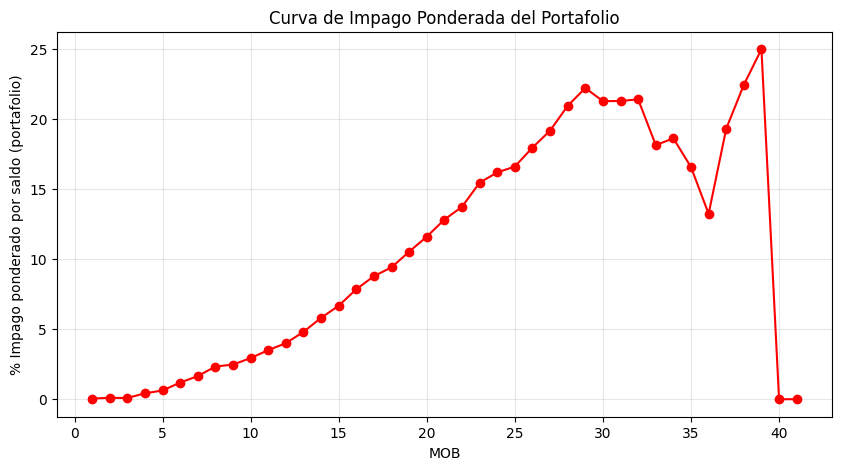

In [24]:
"""
% de saldo total del portafolio que se encuentra en impago a cada mes de vida del crédito.
"""
weighted = (
    agg.groupby("MOB")
       .apply(lambda x: x["bgi4_sum"].sum() / x["saldo_sum"].sum() * 100)
)

plt.figure(figsize=(10, 5))
plt.plot(weighted.index, weighted.values, marker="o", color='red')
plt.xlabel("MOB")
plt.ylabel("% Impago ponderado por saldo (portafolio)")
plt.title("Curva de Impago Ponderada del Portafolio")
plt.grid(True, alpha=0.3)
plt.show()
